In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
from scipy.integrate import solve_ivp
from pathlib import Path

In [9]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"  # Set this to the name of your project root folder
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not find project root folder '{project_folder_name}' from {Path.cwd()}")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *

try:
    from data.load_experiment import load_aux_data_exp
except ModuleNotFoundError:
    from data.export import export_experiment_data as load_aux_data_exp

In [16]:
# Build condition keys and load auxiliary data in a notebook-friendly format.
import re

keys = []
for RHC in [0, 0.5]:
    for P_des in [1.3, 1.4, 1.5]:
        for T_des in [50, 60, 70]:
            if RHC == 0 and P_des != 1.3:
                continue  # not measured on the experimental side
            keys.append(f"RHA0/RHC{RHC}_P{P_des}_T{T_des}")

aux_data_exp = {}
I_points = None

# Keep the columns explicit (no automatic pattern matching).
metric_cols_water = ["D_H2O*", "COND_H2O", "DEB_H2O", "T_H2O_IN", "T_H2O_OUT", "T_H2O_MEAN"]
metric_cols_h2 = ["H2_FLOW", "T_H2", "P_H2", "HR_H2_Gaz", "HR_H2_FC", "DEB_H2*", "T_BOU_H2*", "DEVH2*"]
metric_cols_o2 = ["AIR_FLOW", "T_AIR", "P_AIR", "HR_AIR_Gaz", "HR_AIR_FC", "DEB_AIR*", "T_BOU_AIR*", "DEVAIR* "]
metric_cols = metric_cols_water + metric_cols_h2 + metric_cols_o2

def cond_to_sheet_key(cond_key):
    match = re.match(r"RHA\d+/RHC([\d.]+)_P([\d.]+)_T(\d+)", cond_key)
    if not match:
        return None
    rhc = float(match.group(1))
    p = float(match.group(2))
    t = int(match.group(3))
    p_map = {1.3: "300", 1.4: "400", 1.5: "500"}
    if p not in p_map:
        return None
    hrc = "50" if abs(rhc - 0.5) < 1e-9 else "0"
    return f"T{t}_P{p_map[p]}_HRC{hrc}"

# Try project-specific loader first.
try:
    aux_data_exp = load_aux_data_exp(project_root, stat_log_all, dyn_log_all, I_points)
except Exception:
    from data.export import export_experiment_data
    aux_sheets = export_experiment_data("auxiliary")

    for key in keys:
        sheet_key = cond_to_sheet_key(key)
        df = aux_sheets.get(sheet_key)

        if df is None:
            aux_data_exp[key] = {"states": {}}
            continue

        work = df.copy()
        work["I_LOAD_num"] = pd.to_numeric(work["I_LOAD"], errors="coerce")
        work = work.dropna(subset=["I_LOAD_num"])
        work["I_BIN"] = work["I_LOAD_num"].round().astype(int)

        if I_points is None:
            I_points = sorted(work["I_BIN"].unique().tolist())

        states = {}
        for col in metric_cols:
            vals = pd.to_numeric(work[col], errors="coerce")
            tmp = pd.DataFrame({"I_BIN": work["I_BIN"], "v": vals}).dropna()
            s = tmp.groupby("I_BIN")["v"].mean()
            states[col] = s.reindex(I_points).to_numpy()

        aux_data_exp[key] = {"states": states}

# If custom loader succeeded but did not provide x-axis, infer from first state length.
if I_points is None:
    for item in aux_data_exp.values():
        states = item.get("states", {})
        if states:
            n = len(next(iter(states.values())))
            I_points = list(range(1, n + 1))
            break

if I_points is None:
    I_points = []

loaded = sum(bool(v.get("states")) for v in aux_data_exp.values())
print(f"Loaded conditions with auxiliary states: {loaded}/{len(aux_data_exp)}")

Loaded conditions with auxiliary states: 12/12


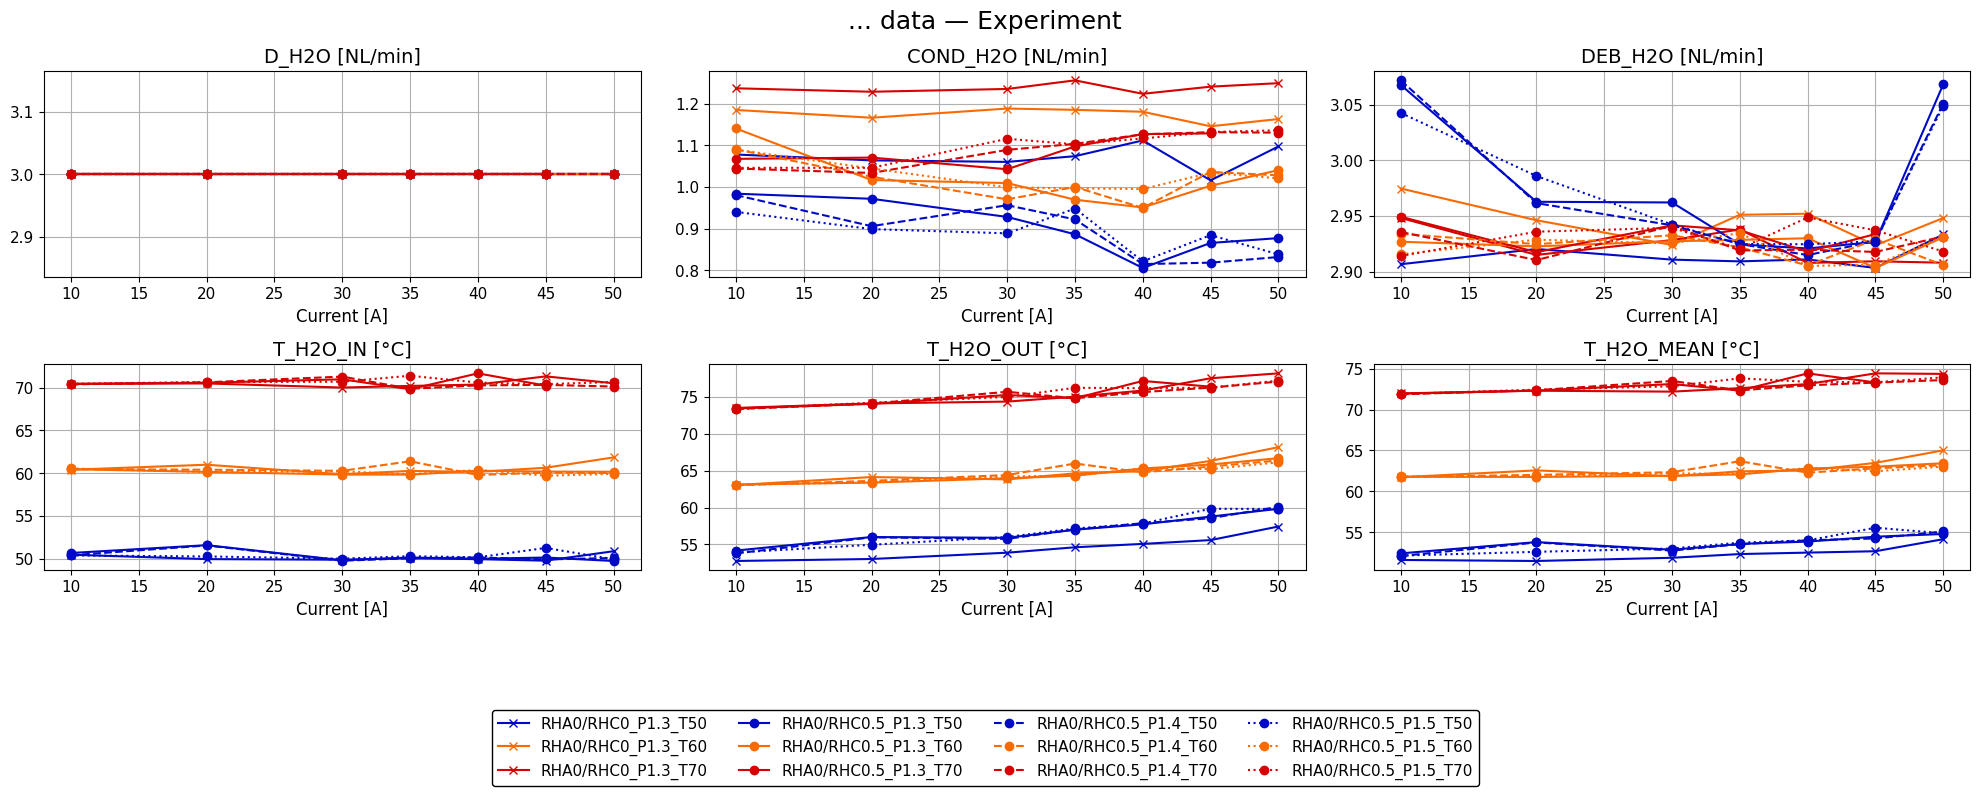

In [20]:
cols_to_plot = [("D_H2O*", "D_H2O [NL/min]"), ("COND_H2O", "COND_H2O [NL/min]"),
                          ("DEB_H2O", "DEB_H2O [NL/min]"), ("T_H2O_IN", "T_H2O_IN [°C]"), ("T_H2O_OUT", "T_H2O_OUT [°C]"), ("T_H2O_MEAN", "T_H2O_MEAN [°C]")]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 8))
fig.suptitle("... data — Experiment", fontsize=18)
handles, labels = [], []
for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    line = None
    for ax, (col, col_label) in zip(axes.flatten(), cols_to_plot):
        if col in exp_states:
            l, = ax.plot(I_points, exp_states[col], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
            if line is None:
                line = l
    if line is None:  # condition had no data — add dummy handle for legend completeness
        line, = axes[0, 0].plot([], [], color=props['color'], linestyle=props['linestyle'], marker=props['marker'])
    handles.append(line)
    labels.append(key)
for ax, (col, col_label) in zip(axes.flatten(), cols_to_plot):
    ax.set_title(col_label, fontsize=14)
    ax.set_xlabel("Current [A]", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
                 ncol=4, fontsize=11, frameon=True, facecolor='white',
                 edgecolor='black', framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

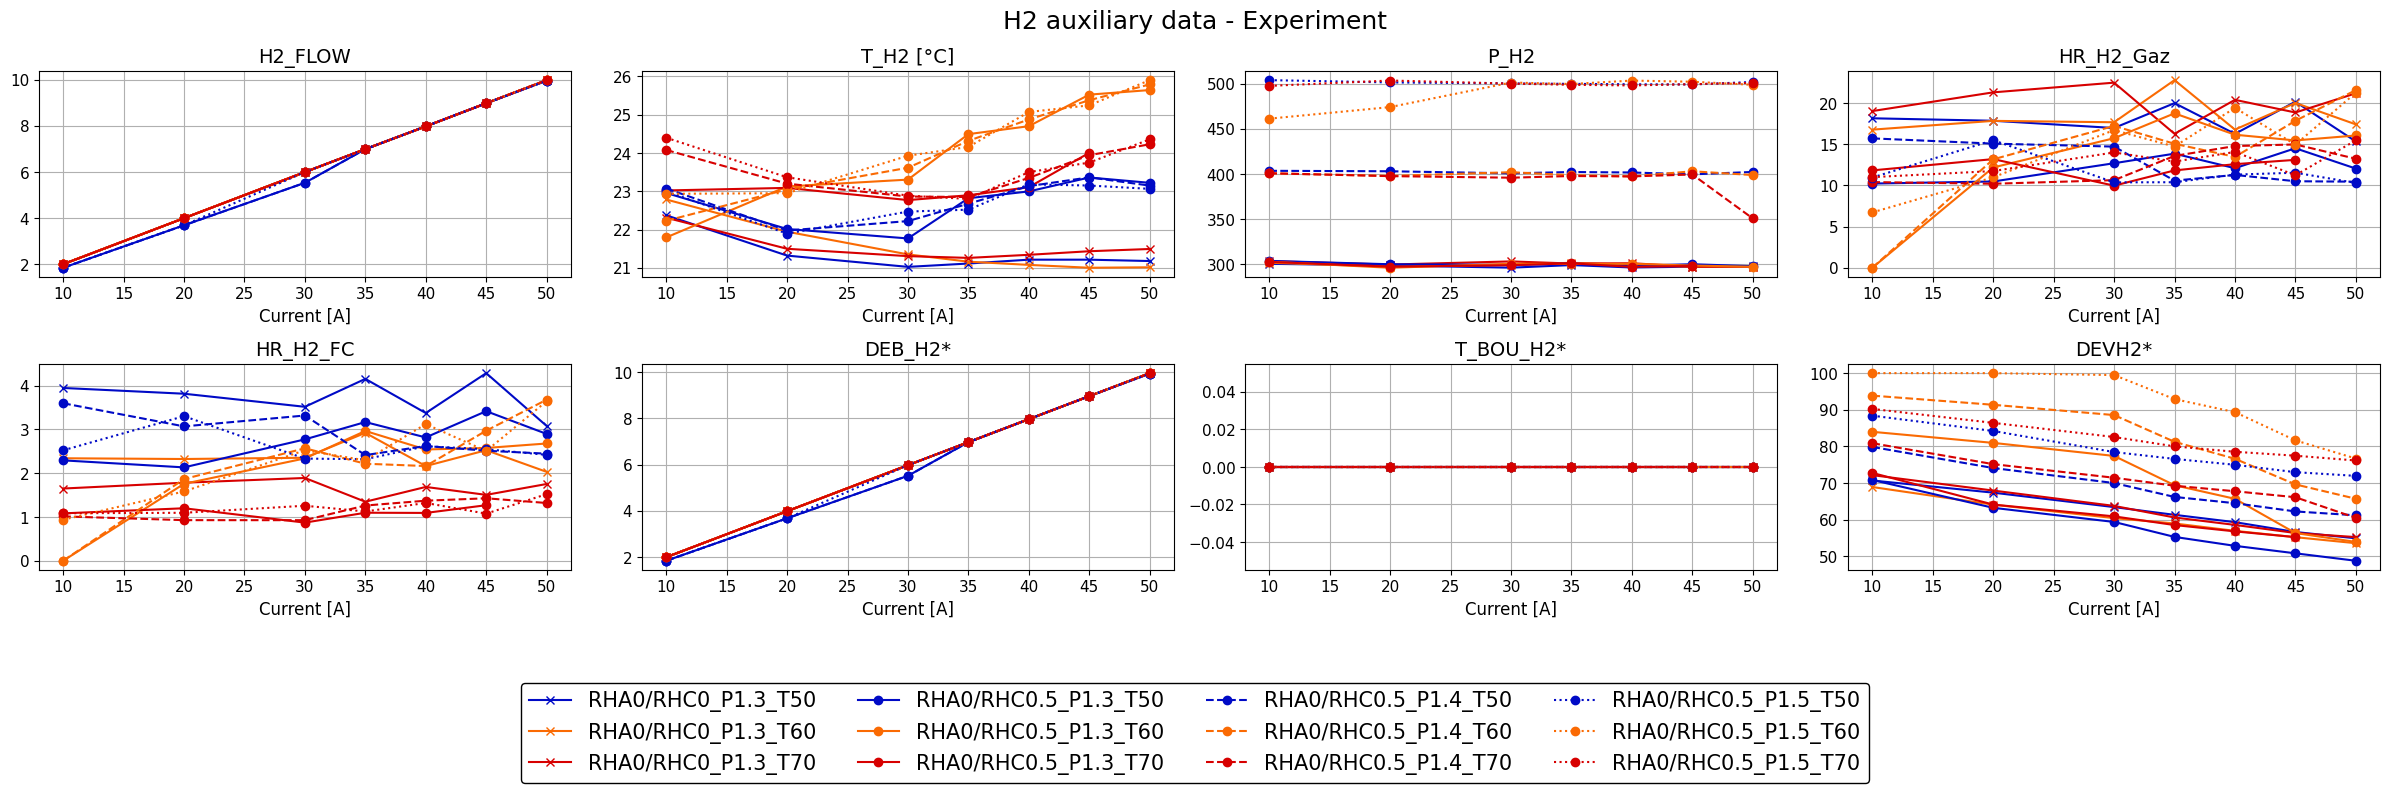

In [23]:
# H2-related auxiliary plots
cols_h2 = [
    ("H2_FLOW", "H2_FLOW"),
    ("T_H2", "T_H2 [°C]"),
    ("P_H2", "P_H2"),
    ("HR_H2_Gaz", "HR_H2_Gaz"),
    ("HR_H2_FC", "HR_H2_FC"),
    ("DEB_H2*", "DEB_H2*"),
    ("T_BOU_H2*", "T_BOU_H2*"),
    ("DEVH2*", "DEVH2*"),
]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 8))
fig.suptitle("H2 auxiliary data - Experiment", fontsize=18)
handles, labels = [], []

for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    line = None
    for ax, (col, col_label) in zip(axes.flatten(), cols_h2):
        l, = ax.plot(I_points, exp_states[col], color=props["color"], linestyle=props["linestyle"], marker=props["marker"])
        if line is None:
            line = l
    handles.append(line)
    labels.append(key)

for ax, (col, col_label) in zip(axes.flatten(), cols_h2):
    ax.set_title(col_label, fontsize=14)
    ax.set_xlabel("Current [A]", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True)

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0),
           ncol=4, fontsize=15, frameon=True, facecolor="white",
           edgecolor="black", framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()

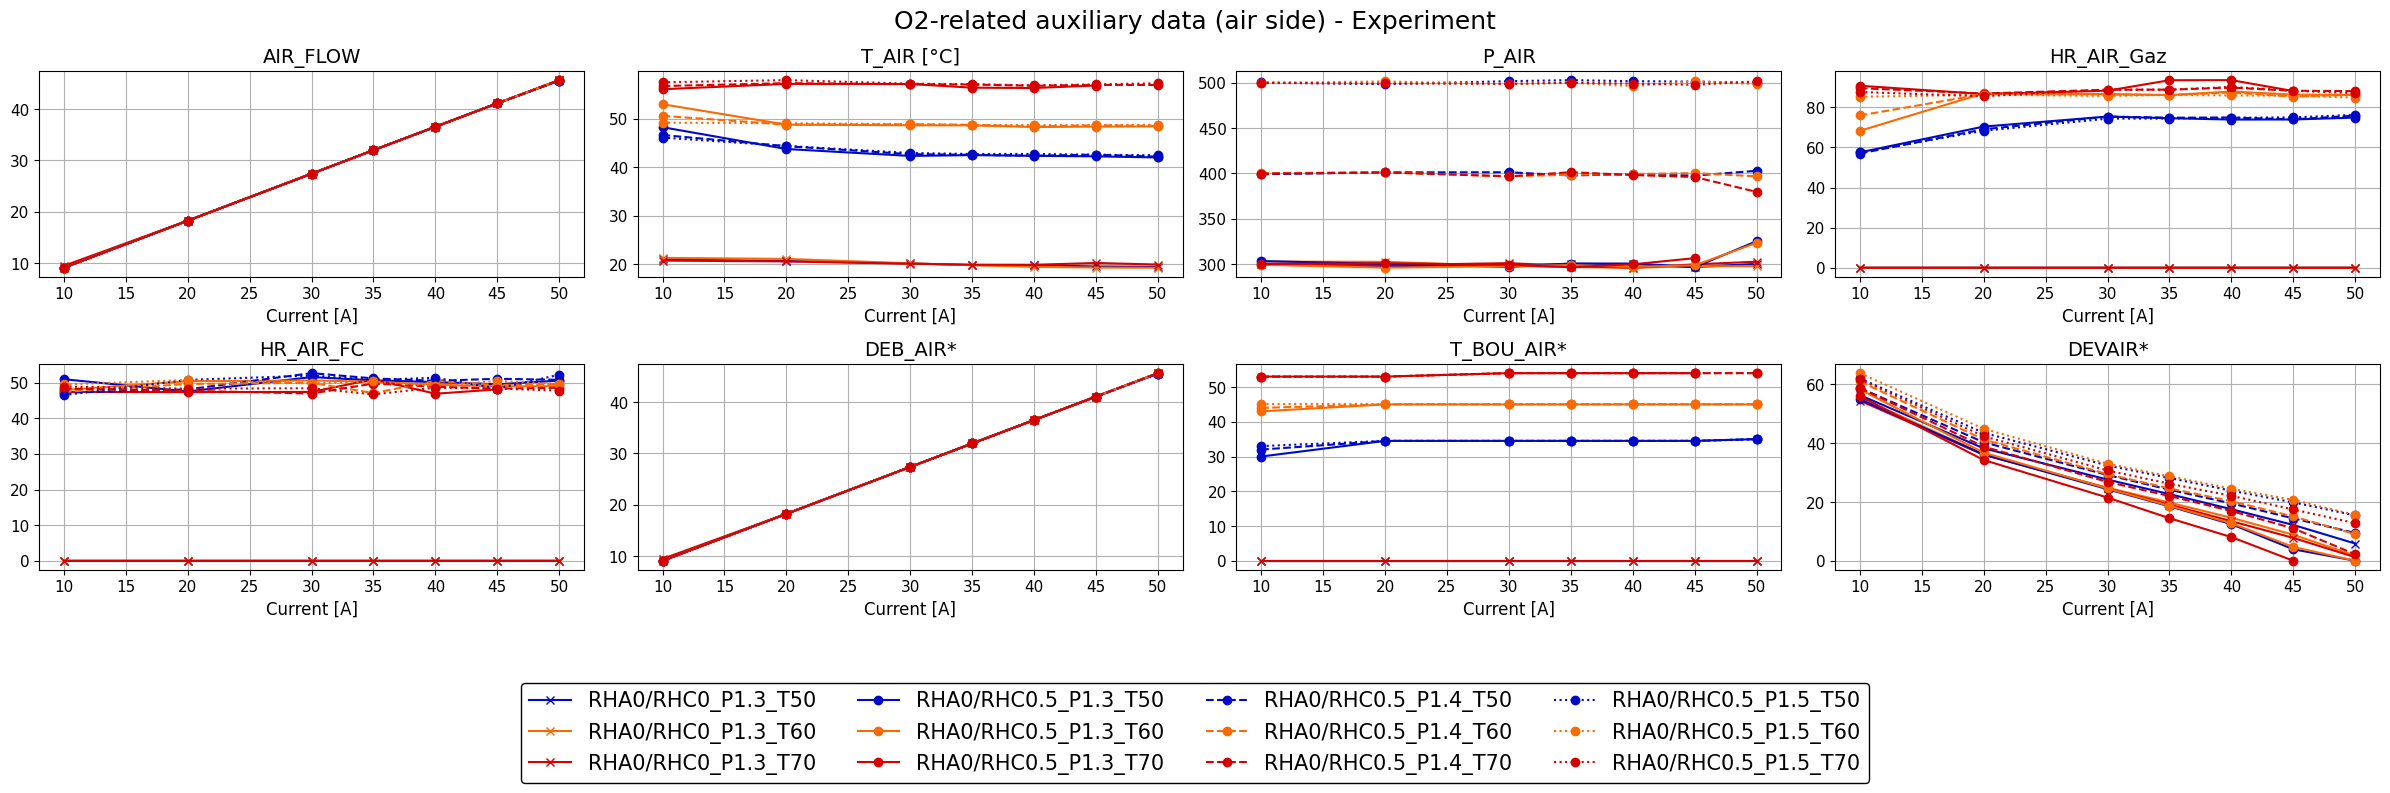

In [24]:
# O2-related auxiliary plots (air side)
cols_o2 = [
    ("AIR_FLOW", "AIR_FLOW"),
    ("T_AIR", "T_AIR [°C]"),
    ("P_AIR", "P_AIR"),
    ("HR_AIR_Gaz", "HR_AIR_Gaz"),
    ("HR_AIR_FC", "HR_AIR_FC"),
    ("DEB_AIR*", "DEB_AIR*"),
    ("T_BOU_AIR*", "T_BOU_AIR*"),
    ("DEVAIR* ", "DEVAIR*"),
]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 8))
fig.suptitle("O2-related auxiliary data (air side) - Experiment", fontsize=18)
handles, labels = [], []

for key in aux_data_exp.keys():
    props = get_plot_properties(key)
    exp_states = aux_data_exp[key].get("states", {})
    line = None
    for ax, (col, col_label) in zip(axes.flatten(), cols_o2):
        l, = ax.plot(I_points, exp_states[col], color=props["color"], linestyle=props["linestyle"], marker=props["marker"])
        if line is None:
            line = l
    handles.append(line)
    labels.append(key)

for ax, (col, col_label) in zip(axes.flatten(), cols_o2):
    ax.set_title(col_label, fontsize=14)
    ax.set_xlabel("Current [A]", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True)

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0),
           ncol=4, fontsize=15, frameon=True, facecolor="white",
           edgecolor="black", framealpha=1.0)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()